<a href="https://colab.research.google.com/github/MatchLab-Imperial/deep-learning-course/blob/master/08_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Reinforcement Learning: An Introduction

In this tutorial, we will enter the world of Deep Reinforcement Learning (DRL). In particular, we will first familiarize ourselves with some basic concepts of Reinforcement Learning (RL), then we will implement a classical tabular Q-learning method for the classic [Frozen Lake](https://gym.openai.com/envs/FrozenLake-v0/) puzzle then implement a Deep Q-learning approach for the [CartPole](https://gym.openai.com/envs/CartPole-v1/) problem, and finally study Proximal Policy Optimization (PPO), a policy-gradient method for the same environment.


>



![alt text](https://media2.giphy.com/media/46ib09ZL1SdWuREnj3/giphy.gif?cid=3640f6095c6e92762f3446634d90bc65) ![alt text](https://media0.giphy.com/media/d9QiBcfzg64Io/200w.webp?cid=3640f6095c6e93e92f30655873731752)![alt text](https://i.gifer.com/GpAY.gif)

The gifs above, show the results obtained by [Deepmind](https://arxiv.org/pdf/1312.5602v1.pdf) in one of their latest papers. They successfully trained an RL agent using deep Q-learning to play classical Atari arcade games. Let's see now how they did it.








# Q-Learning

This family of RL methods try to learn an approximator of the action-value functions $Q(s,a)$  based on the [Bellman equation](https://en.wikipedia.org/wiki/Bellman_equation), such that the update using a classical [gradient descent ](https://en.wikipedia.org/wiki/Gradient_descent) formulation is given by:
$$Q\left(s,a\right)=Q\left(s,a\right)+ \alpha \left(r+\gamma \max _{a} Q\left(s_{t+1},a\right)-Q\left(s,a\right)\right).$$
Where $\alpha$ is the step size.
 Q-Learning updates the estimated reward at each time step and  uses the old estimate $ \max _{a}Q\left(s_{t+1},a\right)$ to update the new ones. In a more algorithmic way, the Q-Learning process is the following:


1.   Initialize Q-values at random $Q\left(s,a\right)$.
2. Forever or until learning is stopped do:
> 1.  Observe state $s$.
> 2.   Take action $a$ according to your policy, e.g., $\epsilon$-greedy.
> 3.   Observe reward $r$ and new state $s_{t+1}$.
> 4. Based on your actual estimates, compute $\max _{a}Q\left(s_{t+1},a\right)$.
> 5. Update your current estimate for  $Q\left(s,a\right)$:
$$Q\left(s,a\right)=Q\left(s,a\right)+ \alpha \left(r+\gamma \max _{a} Q\left(s_{t+1},a\right)-Q\left(s,a\right)\right).$$

Okay, now that we are familiar with Q-Learning lets jump to a real implementation of it.







## Tabular Q-Learning with Frozen Lake
In this section we will teach an agent how to play  the [Frozen lake](https://gym.openai.com/envs/FrozenLake-v0/) game using a classical tabular Q-learning. Brace yourselves, winter is coming!

![alt text](https://raw.githubusercontent.com/simoninithomas/Deep_reinforcement_learning_Course/1ee37cfc3130057f828f19b3cee6066d41c1eeb4/Q%20learning/FrozenLake/frozenlake.png)

Winter has arrived and you and your friends were tossing around a frisbee at the park when you made a wild throw that left the frisbee out in the middle of the lake. The water is mostly frozen, but there are a few holes where the ice has melted. If you step into one of those holes, you'll fall into the freezing water. At this time, there's an international frisbee shortage, so you must navigate across the lake and retrieve the disc. However, the ice is slippery, so you won't always move in the direction you intend.
The goal of this game is to go from the starting state (S) to the goal state (G) by walking only on frozen tiles (F) and avoid holes (H). However, the ice is slippery (!!), so you won't always move in the direction you intend (stochastic environment), i.e., there is a probability $p$ that you move in the direction selected and a probability $(1-p)$ that given the slippery ice, you move to a random position near position. Specifically, let's say you select the action UP, you have a probability of 1/3 of actually going UP, 1/3 of going RIGHT and 1/3 of going LEFT. Similarly, if you select LEFT, you have a probability of 1/3 of actually going LEFT, 1/3 of going UP and 1/3 of going DOWN.

The lake is represented by a 4x4 grid and the location where the frisbee has landed (G) as well as the holes (H) is always the same for every new game. The game is restarted every time you have successfully recovered the frisbee or you have fallen into the cold waters. A reward of +1 is given every time you recover the frisbee and 0 other way.


**Step 0: Import the needed libraries:**

We will be using 3 libraries:

* Numpy for our Qtable.
* OpenAI Gym for our FrozenLake Environment
* Random to generate random numbers



In [2]:
!pip install gymnasium --upgrade

import base64
import collections
import glob
import io
import os
import random
import time
import torch

from IPython import display as ipythondisplay
from IPython.display import HTML
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

def set_seed(seed: int) -> None:
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


**Environment creation:**

OpenAi is  a library composed of many environments that we can use to train our agents, in our case we choose to use the Frozen Lake.

In [ ]:
env = gym.make("FrozenLake-v1", render_mode='rgb_array')

**Q-table**

 Now, we'll create our Q-table. The goal of the Q-table is to store the estimates $Q\left(s,a\right)$ and retrieve them when necessary. In this game the states are represented by each of the 16 grid positions being 0 the starting position and 16 the goal position and the actions are 4: left, right, up and down. Our Q-table will have then $16 \times 4$ positions, where the value of the first column of the first row represents the expected return of being in position 0 and taking left.

The number of rows (states) and columns (actions) the table will have can also be obtained using the values action_size and the state_size from the OpenAI Gym library: *env.action_space.n* and* env.observation_space.n*.

We initialize the table to 0.

In [ ]:
action_size = env.action_space.n
state_size = env.observation_space.n
qtable = np.zeros((state_size, action_size))
print(qtable)

**Hyperparameters**

Following, we specify the hyperparameters:


In [ ]:
total_episodes = 25000        # Total episodes
learning_rate = 0.8           # Learning rate (alpha in the previous formulation)
max_steps = 100               # Max steps per episode
gamma = 0.95                  # Discounting rate

At first, we don't know how to interact with the environment (Q-table values set to 0), so we start exploring it by taking a random action with probability $\epsilon=1$, capturing the rewards obtained and updating the Q-values of the table accordingly. As time passes by, we start knowing more and more the environment, so we reduce (decay_rate) the probability of taking a random action and we start exploiting our knowledge, we choose the action that leads us to the highest reward, i.e., the one with the highest Q-value.

In [ ]:
# Exploration parameters
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.01            # Minimum exploration probability
epsilon = max_epsilon         # Exploration rate
decay_rate = 0.001            # Exponential decay rate for exploration prob

**Q-Learning**

Now we implement the Q-Learning algorithm:
> 1.  Observe state $s$.
> 2.   Choose a random value $v$ between 0 and 1.
> 3. If $v<\epsilon$, we choose a random action, otherwise we select the action with maximum $Q(s,a)$.
> 3.   Observe reward $r$ and new state $s_{t+1}$.
> 4. Based on your previous estimates, compute $\max _{a}Q\left(s_{t+1},a\right)$.
> 5. Update your current estimates for  $Q\left(s,a\right)$:
$$Q\left(s,a\right)=Q\left(s,a\right)+ \alpha \left(r+\gamma \max _{a} Q\left(s_{t+1},a\right)-Q\left(s,a\right)\right).$$


In [ ]:
set_seed(0)

# List of rewards
rewards = []

for episode in range(total_episodes):
    # Reset the environment
    state, _ = env.reset()
    step = 0
    done = False
    total_rewards = 0

    for step in range(max_steps):
        # 3. Choose an action a in the current world state (s)
        ## First we randomize a number
        exp_exp_tradeoff = random.uniform(0, 1)

        ## If this number > greater than epsilon --> exploitation (taking the biggest Q value for this state)
        if exp_exp_tradeoff > epsilon:
            action = np.argmax(qtable[state,:])

        # Else doing a random choice --> exploration
        else:
            action = env.action_space.sample()

        # Take the action (a) and observe the outcome state(s') and reward (r)
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
        # qtable[new_state,:] : all the actions we can take from new state
        qtable[state, action] = qtable[state, action] + learning_rate * (reward + gamma * np.max(qtable[new_state, :]) - qtable[state, action])

        total_rewards += reward

        # Our new state is state
        state = new_state

        # If done (if we're dead) : finish episode
        if done == True:
            break

    # Reduce epsilon (because we need less and less exploration)
    epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*episode)
    rewards.append(total_rewards)

print ("Score over time: " +  str(sum(rewards)/total_episodes))
print(qtable)

**Use our Q-table to play FrozenLake!**

After 25000 episodes, our Q-table can be used as a "cheatsheet" to play FrozenLake"!
  
By running this cell, you can see our agent playing FrozenLake:

In [ ]:
env = gym.make("FrozenLake-v1", render_mode='rgb_array')
state, _ = env.reset()
step = 0

plt.imshow(env.render())
plt.show()

for step in range(max_steps):

    # Take the action (index) that have the maximum expected future reward given that state
    action = np.argmax(qtable[state,:])

    new_state, reward, terminated, truncated, info = env.step(action)
    plt.imshow(env.render())
    plt.show()

    # We print the current step.
    print(f"Number of steps: {step}")
    if terminated or truncated:
      break
    state = new_state

env.close()

Let’s see how many times our agent finds the frisbee 🎉

To this end we will print the last step of the game.

In [ ]:
set_seed(0)

games=5
for game in range(games):
    env = gym.make("FrozenLake-v1")
    state, _ = env.reset()
    step = 0
    for step in range(max_steps):

        # Take the action (index) that have the maximum expected future reward given that state
        action = np.argmax(qtable[state,:])
        new_state, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
        # Here, we decide to only print the last state (to see if our agent is on the goal or fall into a hole)
        # We print the number of step it took.
            print(f"Succeed: {reward == 1}, Number of steps: {step}")
            break
        state = new_state
    env.close()

In [ ]:
set_seed(0)

games = 1000
total_rewards = 0

for game in range(games):
    env = gym.make("FrozenLake-v1")
    state, _ = env.reset()
    step = 0
    for step in range(max_steps):
        # Take the action (index) that have the maximum expected future reward given that state
        action = np.argmax(qtable[state,:])
        new_state, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            total_rewards += reward
            break
        state = new_state
    env.close()
success = total_rewards / games
print("Ratio of sucessfully finished episodes is {:f}".format(success))

## CartPole

That wasn't so hard! How about trying to balance a pole so it does not fall? In this section we will address the [CartPole](https://gym.openai.com/envs/CartPole-v1/) problem, let's get to it!

![texto alternativo](https://keon.github.io/images/deep-q-learning/animation.gif)

As before we will use Q-learning to train our agent, so let's start by constructing our Q-table. We first need to find out the number of columns and rows of it. By checking the environment specifications of [OpenAi](https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py), we see that the actions are left and right, so we need two columns for the actions. On the other hand, the state information is given by:

        Num	Observation                 Min         Max
        0	Cart Position             -4.8            4.8
        1	Cart Velocity             -Inf            Inf
        2	Pole Angle                 -24 deg        24 deg
        3	Pole Velocity At Tip      -Inf            Inf
      
The cart position goes from -4.8 to 4.8 with a resolution of 0.01, which means $\frac{4.8 \times 2}{0.01}=960$ possible carts positions, while the cart velocity goes from $-\infty$ to $\infty$!. How we are going to construct a table with $\infty$ rows?

Do not panic! That is when deep learning steps up and takes over the stage. As you have already seen the use of Deep Neural Networks as general function approximators have been proven to work very well in a wide range of areas, reinforcement learning is not an exception. In this case we will use the NNs as function approximation between the mapping of states to actions, so for every input state, we want the NNs to output an approximation of the $Q\left(s,a\right)$.

![alt text](https://proxy.duckduckgo.com/iu/?u=https%3A%2F%2Fcdn-images-1.medium.com%2Fmax%2F1318%2F1*Gh5PS4R_A5drl5ebd_gNrg%402x.png&f=1)

In this particular scenario, the input layer will have the same number of inputs as environment parameters, 4, and the output layer will have the same number of outputs as actions, in this case 2.

**Reward:** A reward of +1 is provided for every timestep that the pole remains upright. The episode ends when the pole is more than 15 degrees from vertical.



**Step 0: Import the needed libraries**

We start by importing the needed libraries:
We will be using 3 libraries:
* PyTorch: for our DNNs.
* OpenAI Gym: for our CartPole Environment
* Random: to generate random numbers.
* Collections: Collection will be use to create a memory buffer to store the tuples $\left(S_t, A_t, R_t,S_{t+1}\right)$ of transactions.

The idea behind the use of a memory buffer is that most optimization algorithms, including gradient descent, assume that the samples used in an update step are independent and identically distributed. Clearly in the defined environment that is not the case, however, by sampling uniformly the memory buffer with a high number of samples the correlation between contiguous samples is broken and less likely to be correlated samples are used to update the network's weights, leading to a stable optimization of the action-parameter selection.


**The Agent**

Let's start by coding a general DQ-Learning agent. The state and action size are passed as parameters and we configure a replay buffer to have capacity to store 2000 experienced transitions.

In [ ]:
class DQNAgent:
    def __init__(self, state_size, action_size, device=None):
        self.state_size   = state_size
        self.action_size  = action_size
        self.memory       = collections.deque(maxlen=2000)
        self.gamma        = 0.95       # discount rate
        self.epsilon      = 1.0        # exploration rate
        self.epsilon_min  = 0.01
        self.epsilon_decay= 0.995
        self.learning_rate= 0.001

        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model  = self._build_model().to(self.device)
        self.opt    = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.loss_fn= nn.MSELoss()

    def _build_model(self):
        # 2×24 MLP
        model = nn.Sequential(
            nn.Linear(self.state_size, 24),
            nn.ReLU(),
            nn.Linear(24, 24),
            nn.ReLU(),
            nn.Linear(24, self.action_size)  # Q(s, ·) logits (no activation)
        )
        return model

    # ---- replay buffer ----
    def remember(self, state, action, reward, next_state, done):
        # store numpy arrays (state/next_state should be shape (1, state_size))
        self.memory.append((state, action, reward, next_state, done))

    # ---- policies ----
    def act(self, state):
        # state: numpy array shape (1, state_size)
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        self.model.eval()
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=self.device)
            q = self.model(s)  # (1, A)
            return int(torch.argmax(q, dim=1).item())

    def exploit(self, state):
        self.model.eval()
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=self.device)
            q = self.model(s)
            return int(torch.argmax(q, dim=1).item())

    # ---- learning step ----
    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)

        # stack to tensors
        state_b      = torch.as_tensor(np.vstack([m[0] for m in minibatch]),
                                       dtype=torch.float32, device=self.device)   # (B, S)
        action_b     = torch.as_tensor([m[1] for m in minibatch],
                                       dtype=torch.long, device=self.device)      # (B,)
        reward_b     = torch.as_tensor([m[2] for m in minibatch],
                                       dtype=torch.float32, device=self.device)   # (B,)
        next_state_b = torch.as_tensor(np.vstack([m[3] for m in minibatch]),
                                       dtype=torch.float32, device=self.device)   # (B, S)
        done_b       = torch.as_tensor([m[4] for m in minibatch],
                                       dtype=torch.float32, device=self.device)   # (B,)

        # target = r + gamma * max_a' Q(next_state, a'); if done -> r
        self.model.eval()
        with torch.no_grad():
            next_q_max = self.model(next_state_b).max(dim=1).values               # (B,)
            target_scalar = reward_b + self.gamma * next_q_max * (1.0 - done_b)   # (B,)

            # target_f starts as current Q(s,·), then we overwrite the taken action
            target_full = self.model(state_b).clone()                              # (B, A)
            target_full[torch.arange(batch_size), action_b] = target_scalar

        # train to fit full target vector
        self.model.train()
        pred_q = self.model(state_b)                                               # (B, A)
        loss = self.loss_fn(pred_q, target_full)

        self.opt.zero_grad()
        loss.backward()
        self.opt.step()

        # epsilon decay
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    # ---- save/load ----
    def save(self, path):
        torch.save(self.model.state_dict(), path)

    def load(self, path):
        state = torch.load(path, map_location=self.device)
        self.model.load_state_dict(state)
        self.model.to(self.device)
        self.model.eval()

**Main**

Following we implement the training of the agent. (Warning: it takes a while...)

In [ ]:
EPISODES = 200
env = gym.make('CartPole-v1')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
agent = DQNAgent(state_size, action_size)
batch_size = 32

for e in range(EPISODES):
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    for time in range(200):
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = np.reshape(next_state, [1, state_size])
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        if done:
            break

        if len(agent.memory) > batch_size:
            agent.replay(batch_size)
    print("episode: {}/{}, score: {}, e: {:.2}"
                  .format(e, EPISODES, time, agent.epsilon))

Let's now visualize how the agent is performing:

In [ ]:
"""
Utility functions to enable video recording of gym environment and displaying it
To enable video, just do "env = wrap_env(env)""
"""

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")


def wrap_env(env):
  env = gym.wrappers.RecordVideo(env, './video')
  return env

In [ ]:
env = wrap_env(gym.make('CartPole-v1', render_mode='rgb_array'))
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
state, _ = env.reset()
state = np.reshape(state, [1, state_size])
for time in range(200):
    screen = env.render()
    action = agent.exploit(state)
    state, reward, terminated, truncated, _ = env.step(action)
    if terminated or truncated:
      break
    state = np.reshape(state, [1, state_size])

env.close()
show_video()

You can have a look of the tutorials and code prepared by [OpenAI](https://spinningup.openai.com/en/latest/user/introduction.html) for further details on RL.

# Actor–Critic Reinforcement Learning

Deep Q-learning learns action values $Q(s,a)$. **Actor–Critic** methods instead divide the job between two components:

- The **actor**, $\pi_\theta(a\mid s)$, chooses actions.
- The **critic**, $V_\phi(s)$, estimates future return and guides the actor.

### Why use Actor–Critic instead of Q-learning?

- **Direct policy learning:** the actor learns the behavior to execute instead of deriving it from $Q$-values.
- **Stochastic policies:** exploration is built into the action distribution rather than added through a rule such as $\epsilon$-greedy.
- **Continuous actions:** the actor can directly produce a continuous distribution, avoiding a difficult maximization over all possible actions.
- **Less noisy gradients:** the critic provides a learned baseline for policy-gradient updates.

> **Trade-off:** Actor–Critic trains two coupled components. On-policy versions may also use data less efficiently than off-policy Q-learning.

The critic evaluates an action through its **advantage**:

$$A_t \approx \text{return from }s_t - V_\phi(s_t).$$

A positive advantage makes the action more likely; a negative advantage makes it less likely.


## 1. Proximal Policy Optimization

**Proximal Policy Optimization (PPO)** is an on-policy Actor–Critic algorithm. It collects experience, estimates advantages with the critic, and improves the actor using

$$\nabla_\theta J(\theta) \approx \mathbb{E}\left[\nabla_\theta \log \pi_\theta(a_t\mid s_t)\, A_t\right].$$

For CartPole, the actor outputs probabilities for `left` and `right`; the critic outputs one state-value estimate. The same architecture can use a Gaussian actor for continuous actions.

### What is special about PPO?

Large policy-gradient updates can destroy useful behavior. PPO keeps updates conservative by comparing the new policy with the policy that collected the data.

- **Clipping** removes the incentive for excessively large policy changes.
- **Several minibatch epochs** reuse each rollout.
- **Simple, stable updates** approximate the idea of trust-region optimization without a constrained optimizer.


## 2. How PPO performs a proximal update

PPO repeats the following cycle:

<table align="center" style="width:80%; max-width:520px; border-collapse:separate; border-spacing:0; margin:20px auto;">
  <tr><td align="center" style="padding:16px; border:2px solid #4C78A8; border-radius:10px; background:#EEF5FC; color:#000000;"><b>1. Collect a rollout</b><br><small style="color:#000000;">Run the current policy in the environment. Store each state, sampled action, reward, termination flag, old log-probability, and critic value.</small></td></tr>
  <tr><td align="center" style="padding:2px; border:none; font-size:28px; line-height:1.2; color:#4C78A8;">↓</td></tr>
  <tr><td align="center" style="padding:16px; border:2px solid #59A14F; border-radius:10px; background:#F0F8EF; color:#000000;"><b>2. Estimate advantages</b><br><small style="color:#000000;">Use rewards and critic values to compute GAE advantages and value targets. These advantages and the stored old log-probabilities remain fixed during optimization.</small></td></tr>
  <tr><td align="center" style="padding:2px; border:none; font-size:28px; line-height:1.2; color:#4C78A8;">↓</td></tr>
  <tr><td align="center" style="padding:16px; border:2px solid #F28E2B; border-radius:10px; background:#FFF5E8; color:#000000;"><b>3. Optimize actor and critic</b><br><small style="color:#000000;">For several minibatch epochs, recompute current log-probabilities, form the new-to-old probability ratio, and apply PPO clipping. Update the critic toward the fixed value targets and include an entropy bonus for exploration.</small></td></tr>
  <tr><td align="center" style="padding:2px; border:none; font-size:28px; line-height:1.2; color:#4C78A8;">↓</td></tr>
  <tr><td align="center" style="padding:16px; border:2px solid #B07AA1; border-radius:10px; background:#F8F0F7; color:#000000;"><b>4. Refresh the data</b><br><small style="color:#000000;">Discard the rollout after the update epochs. The improved policy becomes the next data-collecting policy, and a fresh on-policy rollout begins the cycle again.</small></td></tr>
</table>

> During optimization, `old_log_prob` and `advantage` stay fixed. Every update compares the current policy with the policy that collected the rollout.


## 3. The probability ratio and clipping

For a sampled state-action pair, PPO compares the probability under the current policy with the probability under the old policy:

$$r_t(\theta)=\frac{\pi_\theta(a_t\mid s_t)}{\pi_{\theta_{old}}(a_t\mid s_t)}
=\exp\left(\log\pi_\theta(a_t\mid s_t)-\log\pi_{\theta_{old}}(a_t\mid s_t)\right).$$

The clipped PPO objective is:

$$L^{CLIP}(\theta)=\mathbb{E}\left[\min\left(r_t(\theta)A_t,\;\operatorname{clip}(r_t(\theta),1-\epsilon,1+\epsilon)A_t\right)\right].$$

With $\epsilon=0.2$ and a positive advantage, increasing a probability from $0.50$ to $0.60$ gives $r_t=1.2$. Moving further to $0.65$ gives $r_t=1.3$, but the clipped term remains $1.2A_t$, so this sample no longer rewards a larger change. For a negative advantage, the lower boundary $1-\epsilon$ plays the analogous role.

Clipping is not a hard rule that every ratio must end at a boundary. It only removes the objective's incentive to push an individual sample farther in the harmful direction.


## 4. Network and action distribution

In the teaching example we use the standard discrete CartPole environment. Its actor outputs two logits; `Categorical(logits=...)` converts them into probabilities for left and right. The critic outputs one scalar state value. The continuous-action extension used in Task 2 is implemented in the Task 2 section so this tutorial remains focused on the discrete actor–critic case.


In [ ]:
from torch.distributions import Categorical

PPO_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PPO device: {PPO_DEVICE}")

class ActorCritic(nn.Module):
    def __init__(self, observation_size, action_space):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(observation_size, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
        )
        self.critic = nn.Linear(64, 1)
        if not isinstance(action_space, gym.spaces.Discrete):
            raise TypeError("The tutorial PPO model expects a Discrete action space.")
        self.actor = nn.Linear(64, action_space.n)

    def get_value(self, observations):
        return self.critic(self.shared(observations)).squeeze(-1)

    def get_action_and_value(self, observations, actions=None):
        features = self.shared(observations)
        distribution = Categorical(logits=self.actor(features))
        if actions is None:
            actions = distribution.sample()
        values = self.critic(features).squeeze(-1)
        return actions, distribution.log_prob(actions), distribution.entropy(), values

    def deterministic_action(self, observations):
        return torch.argmax(self.actor(self.shared(observations)), dim=-1)


## 5. Generalised Advantage Estimation (GAE)

The one-step temporal-difference residual is

$$\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t).$$

GAE combines several future residuals:

$$A_t^{GAE(\gamma,\lambda)} = \delta_t + (\gamma\lambda)\delta_{t+1} + (\gamma\lambda)^2\delta_{t+2}+\cdots$$

`gae_lambda=1` is close to using full Monte-Carlo returns; lower values rely more on the critic and usually have lower variance. The code below computes advantages backwards through the rollout, then constructs value targets for the critic.


In [ ]:
def compute_gae(rewards, values, dones, last_value, gamma=0.99, gae_lambda=0.95):
    """Compute GAE advantages and value targets for one fixed rollout."""
    advantages = torch.zeros_like(rewards)
    gae = 0.0
    for t in reversed(range(len(rewards))):
        next_value = last_value if t == len(rewards) - 1 else values[t + 1]
        non_terminal = 1.0 - dones[t]
        delta = rewards[t] + gamma * next_value * non_terminal - values[t]
        gae = delta + gamma * gae_lambda * non_terminal * gae
        advantages[t] = gae
    return advantages, advantages + values

def collect_rollout(env, model, rollout_steps, device, seed=None):
    """Collect on-policy data from the discrete CartPole environment."""
    observation, _ = env.reset(seed=seed)
    observations, actions, log_probs, rewards, dones, values = [], [], [], [], [], []
    completed_returns, episode_return = [], 0.0
    model.eval()

    for _ in range(rollout_steps):
        observation_tensor = torch.as_tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            action, log_prob, _, value = model.get_action_and_value(observation_tensor)
        next_observation, reward, terminated, truncated, _ = env.step(int(action.item()))
        done = terminated or truncated
        observations.append(observation_tensor.squeeze(0).cpu())
        actions.append(action.squeeze(0).cpu())
        log_probs.append(log_prob.squeeze(0).cpu())
        values.append(value.squeeze(0).cpu())
        rewards.append(torch.tensor(reward, dtype=torch.float32))
        dones.append(torch.tensor(float(done), dtype=torch.float32))
        episode_return += reward
        observation = next_observation
        if done:
            completed_returns.append(episode_return)
            observation, _ = env.reset()
            episode_return = 0.0

    with torch.no_grad():
        last_observation = torch.as_tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
        last_value = model.get_value(last_observation).squeeze(0).cpu()
    rewards, values, dones = torch.stack(rewards), torch.stack(values), torch.stack(dones)
    advantages, returns = compute_gae(rewards, values, dones, last_value)
    return {"observations": torch.stack(observations), "actions": torch.stack(actions),
            "old_log_probs": torch.stack(log_probs), "advantages": advantages,
            "returns": returns, "old_values": values, "completed_returns": completed_returns}


## 6. PPO update and clipping diagnostics

The update is identical for categorical and Gaussian actors because both provide scalar log-probabilities. `use_clipping=False` gives the ordinary importance-weighted surrogate and is used later as an ablation.

`clip_fraction` is always measured against $1\pm\epsilon$. For an un-clipped run, it means “the fraction that would have been clipped”; this makes movement of the two policies directly comparable. `approx_kl` is another indicator of update size.


In [35]:
def ppo_update(model, optimizer, batch, device, clip_epsilon=0.2,
               use_clipping=True, update_epochs=6, minibatch_size=64,
               value_coef=0.5, entropy_coef=0.01):
    observations = batch["observations"].to(device)
    actions = batch["actions"].to(device)
    old_log_probs = batch["old_log_probs"].to(device)
    returns = batch["returns"].to(device)
    advantages = batch["advantages"].to(device)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    metrics = collections.defaultdict(list)

    model.train()
    for _ in range(update_epochs):
        permutation = torch.randperm(len(observations), device=device)
        for indices in permutation.split(minibatch_size):
            _, new_log_probs, entropy, new_values = model.get_action_and_value(
                observations[indices], actions[indices]
            )
            log_ratio = new_log_probs - old_log_probs[indices]
            ratio = log_ratio.exp()
            surrogate = ratio * advantages[indices]
            clipped_surrogate = torch.clamp(
                ratio, 1 - clip_epsilon, 1 + clip_epsilon
            ) * advantages[indices]
            if use_clipping:
                policy_loss = -torch.minimum(surrogate, clipped_surrogate).mean()
            else:
                policy_loss = -surrogate.mean()

            value_loss = 0.5 * (returns[indices] - new_values).pow(2).mean()
            entropy_bonus = entropy.mean()
            loss = policy_loss + value_coef * value_loss - entropy_coef * entropy_bonus

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()

            metrics["policy_loss"].append(policy_loss.item())
            metrics["value_loss"].append(value_loss.item())
            metrics["entropy"].append(entropy_bonus.item())
            metrics["approx_kl"].append(((ratio - 1.0) - log_ratio).mean().item())
            metrics["clip_fraction"].append(((ratio - 1.0).abs() > clip_epsilon).float().mean().item())
    return {name: float(np.mean(values)) for name, values in metrics.items()}


## 7. Train discrete-action PPO on CartPole

Each update collects fresh on-policy data from standard discrete `CartPole-v1`, then performs several epochs on that fixed rollout. The continuous-control PPO implementation used for the Pendulum task appears in the Task 2 section below.


In [ ]:
PPO_SEED = 0
PPO_ROLLOUT_STEPS = 1024
PPO_UPDATES = 25
PPO_LR = 3e-4
PPO_CLIP_EPSILON = 0.2

def evaluate_ppo(model, device, episodes=10, seed=10_000):
    env = gym.make("CartPole-v1")
    returns = []
    model.eval()
    for episode in range(episodes):
        observation, _ = env.reset(seed=seed + episode)
        total_reward = 0.0
        while True:
            observation_tensor = torch.as_tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                action = model.deterministic_action(observation_tensor)
            environment_action = int(action.item())
            observation, reward, terminated, truncated, _ = env.step(environment_action)
            total_reward += reward
            if terminated or truncated:
                break
        returns.append(total_reward)
    env.close()
    return float(np.mean(returns))

def train_ppo(seed=PPO_SEED, clip_epsilon=PPO_CLIP_EPSILON,
              use_clipping=True, updates=PPO_UPDATES, rollout_steps=PPO_ROLLOUT_STEPS,
              evaluation_episodes=5, verbose=True):
    set_seed(seed)
    env = gym.make("CartPole-v1")
    model = ActorCritic(env.observation_space.shape[0], env.action_space).to(PPO_DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=PPO_LR)
    history = collections.defaultdict(list)

    for update in range(updates):
        batch = collect_rollout(env, model, rollout_steps, PPO_DEVICE, seed + update)
        metrics = ppo_update(
            model, optimizer, batch, PPO_DEVICE,
            clip_epsilon=clip_epsilon, use_clipping=use_clipping,
        )
        train_return = np.mean(batch["completed_returns"]) if batch["completed_returns"] else np.nan
        evaluation_return = evaluate_ppo(
            model, PPO_DEVICE, episodes=evaluation_episodes,
            seed=20_000 + 100 * seed + 10 * update,
        )
        history["train_return"].append(train_return)
        history["eval_return"].append(evaluation_return)
        for name, value in metrics.items():
            history[name].append(value)
        if verbose:
            print(f"update {update + 1:02d}/{updates}: eval return={evaluation_return:7.1f}, "
                  f"KL={metrics['approx_kl']:.4f}, outside clip range={metrics['clip_fraction']:.3f}")
    env.close()
    return model, history

ppo_model, ppo_history = train_ppo()


## 8. Inspect the discrete learning process

The CartPole evaluation return should increase toward the environment maximum of 500. Approximate KL and the fraction of ratios outside the clip range diagnose how far the current actor has moved from the rollout actor. Values vary by seed, so focus on the trend rather than an exact number.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(ppo_history["eval_return"], marker="o")
axes[0].set(title="Greedy evaluation return", xlabel="PPO update", ylabel="mean return (10 episodes)")
axes[1].plot(ppo_history["approx_kl"], marker="o")
axes[1].set(title="Approximate KL", xlabel="PPO update", ylabel="old vs. current policy")
axes[2].plot(ppo_history["clip_fraction"], marker="o")
axes[2].set(title="Clip fraction", xlabel="PPO update", ylabel="fraction of sampled ratios")
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Coursework

## Task 1 — On-policy and off-policy learning with CliffWalking

In **CliffWalking**, the agent starts at the bottom-left of a 4×12 grid and must reach the bottom-right goal. The cells between them are a cliff. Each ordinary transition receives reward `-1`. Stepping into the cliff receives `-100` and returns the agent to the start; reaching the goal ends the episode.

![Animated CliffWalking Q-learning rollout](assets/cliffwalking-qlearning.gif)

*Animated Q-learning rollout. Source: [VachanVY/Reinforcement-Learning](https://github.com/VachanVY/Reinforcement-Learning).*

The environment has 48 discrete states and four actions, so a Q-table is sufficient. The shortest route runs immediately above the cliff. It is efficient if every action is greedy, but a single exploratory downward action can cause a large penalty.

### Learning objectives

1. Implement Q-learning as an off-policy method and SARSA as an on-policy method.
2. Distinguish the greedy target policy from the exploring behaviour policy.
3. Use learned routes and state-visitation patterns to explain why SARSA can learn a safer policy.


### 1. Experiment configuration

The main comparison uses the classical deterministic CliffWalking setting: $\gamma=1$, a fixed $\epsilon=0.1$, and `is_slippery=False`. Keeping exploration active is important because SARSA learns the value of the behaviour policy it is actually following. Use the same settings and seed for both algorithms.


In [3]:
ENV_NAME = "CliffWalking-v1"
EPISODES = 500
MAX_STEPS = 200
ALPHA = 0.5
GAMMA = 1.0
EPSILON = 0.1
IS_SLIPPERY = False
TRAIN_SEED = 7

env = gym.make(ENV_NAME, is_slippery=IS_SLIPPERY)
print(f"States: {env.observation_space.n}; actions: {env.action_space.n}; "
      f"slippery: {IS_SLIPPERY}")
env.close()


States: 48; actions: 4; slippery: False


### 2. The shared behaviour policy

Both agents collect experience with the same **$\epsilon$-greedy behaviour policy**:

- with probability $1-\epsilon$, choose an action with the largest current Q-value;
- with probability $\epsilon$, choose a random action.

Here $\epsilon$ remains at `0.1` during training and behaviour-policy evaluation. Random tie-breaking avoids always preferring the first action when several Q-values are equal. The helper is complete and should not be modified.


In [4]:
def choose_action(q_values, epsilon, rng):
    """Sample an epsilon-greedy action with random tie-breaking."""
    if rng.random() < epsilon:
        return int(rng.integers(len(q_values)))
    best = np.flatnonzero(q_values == np.max(q_values))
    return int(rng.choice(best))


### 3. The learning target

Both algorithms update the observed state-action pair $(s,a)$ after receiving $(r,s')$. They differ only in the value used at the next state.

**Q-learning (off-policy)** learns about a greedy target policy even while the behaviour policy explores:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right].$$

**SARSA (on-policy)** learns about the same $\epsilon$-greedy policy that generates the experience. It samples the next behaviour action $a'$ and uses that action in its target:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\left[r + \gamma Q(s',a') - Q(s,a)\right].$$

Near the cliff, Q-learning's target assumes that the next action will be greedy. SARSA's target includes the consequences of occasional exploratory actions. A route with more space below it can therefore have a better value for SARSA, even though it takes more steps.


### 4. Train Q-learning first

Q-learning is provided as a complete baseline. Its target always uses the largest action value at the next state, while its next behaviour action is sampled separately with the $\epsilon$-greedy policy.

Run this cell first. It should train without any student changes.


In [5]:
def train_q_learning(seed=TRAIN_SEED, episodes=EPISODES,
                     alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON):
    env = gym.make(ENV_NAME, is_slippery=IS_SLIPPERY)
    rng = np.random.default_rng(seed)
    q_table = np.zeros((env.observation_space.n, env.action_space.n), dtype=np.float64)
    rewards, steps, cliff_falls, td_errors = [], [], [], []

    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        total_reward, fell, episode_td_errors = 0, False, []

        for step in range(MAX_STEPS):
            action = choose_action(q_table[state], epsilon, rng)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            fell = fell or (reward == -100)

            # Off-policy target: learn about the greedy next action.
            next_value = 0.0 if done else np.max(q_table[next_state])
            target = reward + gamma * next_value
            td_error = target - q_table[state, action]
            q_table[state, action] += alpha * td_error
            episode_td_errors.append(abs(td_error))

            if done:
                break
            state = next_state

        rewards.append(total_reward)
        steps.append(step + 1)
        cliff_falls.append(int(fell))
        td_errors.append(np.mean(episode_td_errors))

    env.close()
    return {"q_table": q_table, "rewards": np.array(rewards),
            "steps": np.array(steps), "cliff_falls": np.array(cliff_falls),
            "td_errors": np.array(td_errors)}


q_learning_result = train_q_learning()
print("Q-learning training complete")


Q-learning training complete


### 5. Complete and train SARSA

SARSA is shown separately so that its action flow is easy to compare with Q-learning. Unlike Q-learning, SARSA selects the next behaviour action **before** updating and uses that same action both in the target and in the next environment step.

Complete only the two marked parts. Use these hints:

1. For a non-terminal transition, select `next_action` with `choose_action`, then use `q_table[next_state, next_action]` as `next_value`. For a terminal transition, use zero and set `next_action` to `None`.
2. After a non-terminal update, carry the **same** `next_action` into the next iteration.

Then run the cell to train SARSA.


In [ ]:
def train_sarsa(seed=TRAIN_SEED, episodes=EPISODES,
                alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON):
    env = gym.make(ENV_NAME, is_slippery=IS_SLIPPERY)
    rng = np.random.default_rng(seed)
    q_table = np.zeros((env.observation_space.n, env.action_space.n), dtype=np.float64)
    rewards, steps, cliff_falls, td_errors = [], [], [], []

    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        action = choose_action(q_table[state], epsilon, rng)
        total_reward, fell, episode_td_errors = 0, False, []

        for step in range(MAX_STEPS):
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            fell = fell or (reward == -100)

            # TODO 1: Construct the SARSA bootstrap value.
            # Hint: SARSA learns about the action its behaviour policy will
            # actually take next. A terminal state has no future value.
            raise NotImplementedError("Complete the SARSA next-action target.")

            # On-policy target: use the next action selected by the behaviour policy.
            target = reward + gamma * next_value
            td_error = target - q_table[state, action]
            q_table[state, action] += alpha * td_error
            episode_td_errors.append(abs(td_error))

            if done:
                break

            # TODO 2: Advance the state-action pair.
            # Hint: reuse the action involved in the bootstrap target rather
            # than asking the behaviour policy for another sample.
            raise NotImplementedError("Carry the SARSA state and action forward.")

        rewards.append(total_reward)
        steps.append(step + 1)
        cliff_falls.append(int(fell))
        td_errors.append(np.mean(episode_td_errors))

    env.close()
    return {"q_table": q_table, "rewards": np.array(rewards),
            "steps": np.array(steps), "cliff_falls": np.array(cliff_falls),
            "td_errors": np.array(td_errors)}


sarsa_result = train_sarsa()
print("SARSA training complete")


### 6. Collect the two results

Both agents have now been trained independently with the same seed, environment and $\epsilon$-greedy behaviour policy. Store them together for the controlled comparison below.


In [7]:
results = {
    "Q-learning": q_learning_result,
    "SARSA": sarsa_result,
}


### 7. Compare training returns

Each curve is the mean return over a 20-episode moving window. Returns include exploratory actions and cliff penalties, so they measure how well each agent behaves while it is still using $\epsilon=0.1$. Because returns are negative, a curve closer to zero is better.


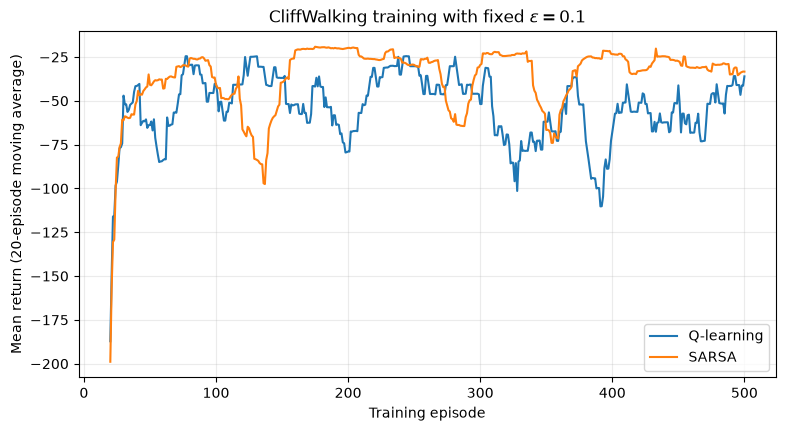

In [8]:
def moving_average(values, window=20):
    return np.convolve(values, np.ones(window) / window, mode="valid")

plt.figure(figsize=(9, 4.5))
for name, result in results.items():
    smooth = moving_average(result["rewards"])
    plt.plot(np.arange(len(smooth)) + 20, smooth, label=name)
plt.xlabel("Training episode")
plt.ylabel("Mean return (20-episode moving average)")
plt.title("CliffWalking training with fixed $\epsilon=0.1$")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### 8. Evaluate both the greedy and behaviour policies

Two evaluations answer different questions:

- **Greedy (`epsilon=0`)** shows the route preferred by the final Q-table when there is no exploration.
- **Behaviour (`epsilon=0.1`)** measures the policy SARSA was trained to improve and exposes the risk of acting near the cliff.

`mean_cliff_distance` is the mean vertical distance from visited non-terminal states to the cliff row. Larger values indicate that the agent usually travels farther from the cliff.


In [10]:
def evaluate_policy(q_table, epsilon, episodes=1000, seed=10_000):
    env = gym.make(ENV_NAME, is_slippery=IS_SLIPPERY)
    rng = np.random.default_rng(seed)
    returns, steps, successes, falls, distances = [], [], 0, 0, []
    visits = np.zeros(env.observation_space.n, dtype=np.int64)

    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        total_reward, fell = 0, False

        for step in range(MAX_STEPS):
            action = choose_action(q_table[state], epsilon, rng)
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            fell = fell or (reward == -100)
            visits[state] += 1

            row, _ = divmod(state, 12)
            if state not in {36, 47}:  # Exclude start and goal from distance summary.
                distances.append(3 - row)
            if terminated or truncated:
                break

        returns.append(total_reward)
        steps.append(step + 1)
        successes += int(terminated and state == 47)
        falls += int(fell)

    env.close()
    return {"mean_return": float(np.mean(returns)),
            "mean_steps": float(np.mean(steps)),
            "success_rate": successes / episodes,
            "cliff_rate": falls / episodes,
            "mean_cliff_distance": float(np.mean(distances)),
            "visits": visits.reshape(4, 12)}

evaluations = {}
for name, result in results.items():
    for label, epsilon in [("greedy", 0.0), ("behaviour", EPSILON)]:
        evaluations[(name, label)] = evaluate_policy(result["q_table"], epsilon)

evaluation_df = __import__("pandas").DataFrame({
    key: {metric: value for metric, value in data.items() if metric != "visits"}
    for key, data in evaluations.items()
}).T
evaluation_df.index.names = ["algorithm", "evaluation_policy"]
evaluation_df.round(3)


mean_return  mean_steps  success_rate  \
algorithm  evaluation_policy                                          
Q-learning greedy                 -13.000      13.000           1.0   
           behaviour              -44.431      16.513           1.0   
SARSA      greedy                 -19.000      19.000           1.0   
           behaviour              -24.123      21.450           1.0   

                              cliff_rate  mean_cliff_distance  
algorithm  evaluation_policy                                   
Q-learning greedy                  0.000                1.000  
           behaviour               0.222                1.113  
SARSA      greedy                  0.000                2.278  
           behaviour               0.027                2.264

### 9. Visualise the learned routes using State-Visitation Heatmaps

The black line is the final greedy route. The blue background shows average state visits per episode over 1,000 rollouts while the agent continues to use $\epsilon=0.1$. Red cells are the cliff, `S` is the start, and `G` is the goal.

This figure makes the central comparison visible: Q-learning normally chooses the short route one row above the cliff, while SARSA tends to move into the upper rows to reduce the cost of exploratory mistakes. The behaviour-policy heatmap shows that this is not just one selected episode; it summarises all evaluation rollouts.


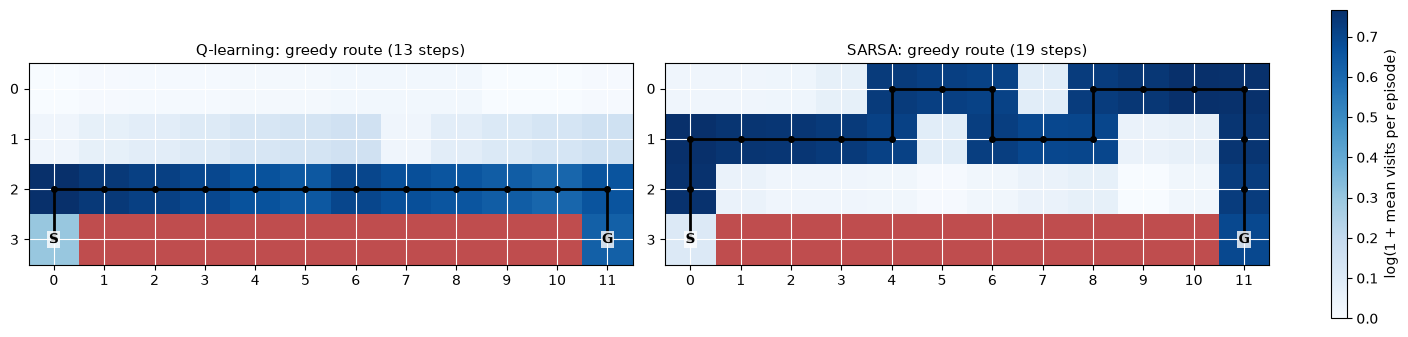

In [11]:
def greedy_path(q_table):
    env = gym.make(ENV_NAME, is_slippery=IS_SLIPPERY)
    state, _ = env.reset(seed=0)
    path = [state]
    for _ in range(MAX_STEPS):
        best = np.flatnonzero(q_table[state] == np.max(q_table[state]))
        action = int(best[0])
        state, _, terminated, truncated, _ = env.step(action)
        path.append(state)
        if terminated or truncated:
            break
    env.close()
    return path

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), constrained_layout=True)
for ax, (name, result) in zip(axes, results.items()):
    visits = evaluations[(name, "behaviour")]["visits"] / 1000
    image = ax.imshow(np.log1p(visits), cmap="Blues", origin="upper")

    for col in range(1, 11):
        ax.add_patch(plt.Rectangle((col - 0.5, 2.5), 1, 1,
                                   facecolor="firebrick", alpha=0.8))

    path = greedy_path(result["q_table"])
    rows, cols = zip(*(divmod(state, 12) for state in path))
    ax.plot(cols, rows, "o-", color="black", linewidth=2, markersize=4)
    label_box = {"facecolor": "white", "alpha": 0.8, "edgecolor": "none", "pad": 1}
    ax.text(0, 3, "S", ha="center", va="center", color="black",
            fontweight="bold", bbox=label_box)
    ax.text(11, 3, "G", ha="center", va="center", color="black",
            fontweight="bold", bbox=label_box)
    ax.set_xticks(range(12))
    ax.set_yticks(range(4))
    ax.set_xlim(-0.5, 11.5)
    ax.set_ylim(3.5, -0.5)
    ax.grid(color="white", linewidth=0.8)
    ax.set_title(f"{name}: greedy route ({len(path) - 1} steps)", fontsize=11)

fig.colorbar(image, ax=axes, shrink=0.75, label="log(1 + mean visits per episode)")
plt.show()


## Submission

You should submit the following to Canvas:

1. Your completed **two-part SARSA implementation**.
2. A **Return vs Episode** figure for Q-learning and SARSA.
3. The **Executed Evaluation table** containing both greedy and behaviour-policy rows.
4. The **State-Visitation Heatmap** for both algorithms.
5. A short **interpretation** that answers all three questions:
   - Which algorithm learned the shorter greedy route, and which learned the route farther from the cliff? Refer to the figure and `mean_cliff_distance`.
   - Why can Q-learning have a safe greedy evaluation but a much worse return or cliff rate when $\epsilon=0.1$?
   - How does the different bootstrap target cause SARSA to account for exploratory actions while Q-learning does not?


# Task 2 — Continuous-control PPO on Pendulum

This task uses PPO for a genuinely continuous-control problem: balancing and swinging up Gymnasium's `Pendulum-v1`.

`Pendulum-v1` has a three-dimensional observation and one continuous action in `[-2, 2]`, representing torque. At each time step the agent chooses both the direction and magnitude of the torque. 

We compare clipped PPO with the ordinary, un-clipped importance-weighted surrogate. Both variants use the same environment, network, rollout length, optimizer, and seeds, so the comparison isolates the effect of clipping while learning a continuous policy.


## Continuous actor and PPO implementation

The actor outputs the mean of a Gaussian distribution and learns its log standard deviation. A raw Gaussian sample must be squashed through `tanh`, then rescaled from `[-1, 1]` to the environment action range `[-2, 2]`.

### Student tasks — continuous action policy

Complete two focused methods in the code cell below:

1. `_distribution_and_value()`: use the shared representation to define both a Gaussian policy and a state-value prediction. Remember that a standard deviation must be positive.
2. `_squash_and_scale()`: first bound an unrestricted sample, then map the bounded interval onto Pendulum's action limits.

All remaining PPO code is provided, including action sampling, inverse action transformation, and the corrected log-probability calculation.


In [ ]:
import collections

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal


def set_task2_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


TASK2_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Task 2 device: {TASK2_DEVICE}")


class PendulumActorCritic(nn.Module):
    """Gaussian actor and value critic for one-dimensional continuous actions."""

    def __init__(self, observation_space, action_space):
        super().__init__()
        observation_size = int(np.prod(observation_space.shape))
        action_size = int(np.prod(action_space.shape))

        self.shared = nn.Sequential(
            nn.Linear(observation_size, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
        )
        self.actor_mean = nn.Linear(64, action_size)
        self.actor_log_std = nn.Parameter(torch.full((action_size,), -0.5))
        self.critic = nn.Linear(64, 1)

        action_low = torch.as_tensor(action_space.low, dtype=torch.float32)
        action_high = torch.as_tensor(action_space.high, dtype=torch.float32)
        self.register_buffer("action_scale", (action_high - action_low) / 2.0)
        self.register_buffer("action_bias", (action_high + action_low) / 2.0)

    def get_value(self, observations):
        return self.critic(self.shared(observations)).squeeze(-1)

    def _distribution_and_value(self, observations):
        """Build the state-conditioned Gaussian policy and critic prediction."""
        # TODO: Use self.shared(observations) to obtain features. From those
        # features, construct the action mean, positive standard deviation,
        # Normal distribution, and critic value.
        #
        # features = ...
        # mean = ...
        # standard_deviation = ... (Have to be positive)
        # distribution = ...
        # values = ...
        # return distribution, values
        raise NotImplementedError("Implement the Gaussian distribution and critic value.")

    def _squash_and_scale(self, raw_actions):
        """Map unbounded Gaussian actions to Pendulum's valid torque range."""
        # TODO: squash raw_actions with tanh, then rescale them with
        # self.action_scale and self.action_bias. Return both tensors as
        # (squashed_actions, actions).
        raise NotImplementedError("Implement the bounded continuous-action transform.")

    def get_action_and_value(self, observations, actions=None):
        """Sample a continuous action or evaluate a supplied action under the policy."""
        distribution, values = self._distribution_and_value(observations)

        if actions is None:
            raw_actions = distribution.rsample()
            squashed_actions, actions = self._squash_and_scale(raw_actions)
        else:
            squashed_actions = ((actions - self.action_bias) / self.action_scale).clamp(
                -0.999999, 0.999999
            )
            raw_actions = torch.atanh(squashed_actions)

        log_det_jacobian = torch.log(
            self.action_scale * (1 - squashed_actions.pow(2)) + 1e-6
        )
        log_probability = (
            distribution.log_prob(raw_actions) - log_det_jacobian
        ).sum(dim=-1)
        entropy = distribution.entropy().sum(dim=-1)
        return actions, log_probability, entropy, values

    def deterministic_action(self, observations):
        features = self.shared(observations)
        _, actions = self._squash_and_scale(self.actor_mean(features))
        return actions


## Rollout collection and PPO update

The rollout stores actions and log-probabilities from the policy that generated the data. During the update, those stored values remain fixed while the current policy is optimized for several epochs.
You don't need to change anything in this cell.


In [15]:
def compute_gae(rewards, values, dones, last_value, gamma=0.99, gae_lambda=0.95):
    advantages = torch.zeros_like(rewards)
    gae = 0.0

    for t in reversed(range(len(rewards))):
        next_value = last_value if t == len(rewards) - 1 else values[t + 1]
        non_terminal = 1.0 - dones[t]
        delta = rewards[t] + gamma * next_value * non_terminal - values[t]
        gae = delta + gamma * gae_lambda * non_terminal * gae
        advantages[t] = gae

    return advantages, advantages + values


def collect_pendulum_rollout(env, model, rollout_steps, device, seed=None):
    observation, _ = env.reset(seed=seed)
    observations, actions, log_probs = [], [], []
    rewards, dones, values = [], [], []
    completed_returns = []
    episode_return = 0.0
    model.eval()

    for _ in range(rollout_steps):
        observation_tensor = torch.as_tensor(
            observation, dtype=torch.float32, device=device
        ).unsqueeze(0)
        with torch.no_grad():
            action, log_prob, _, value = model.get_action_and_value(observation_tensor)

        environment_action = action.squeeze(0).cpu().numpy()
        next_observation, reward, terminated, truncated, _ = env.step(environment_action)
        done = terminated or truncated

        observations.append(observation_tensor.squeeze(0).cpu())
        actions.append(action.squeeze(0).cpu())
        log_probs.append(log_prob.squeeze(0).cpu())
        rewards.append(torch.tensor(reward, dtype=torch.float32))
        dones.append(torch.tensor(float(done), dtype=torch.float32))
        values.append(value.squeeze(0).cpu())

        episode_return += reward
        observation = next_observation
        if done:
            completed_returns.append(episode_return)
            observation, _ = env.reset()
            episode_return = 0.0

    with torch.no_grad():
        last_observation = torch.as_tensor(
            observation, dtype=torch.float32, device=device
        ).unsqueeze(0)
        last_value = model.get_value(last_observation).squeeze(0).cpu()

    rewards = torch.stack(rewards)
    values = torch.stack(values)
    dones = torch.stack(dones)
    advantages, returns = compute_gae(rewards, values, dones, last_value)

    return {
        "observations": torch.stack(observations),
        "actions": torch.stack(actions),
        "old_log_probs": torch.stack(log_probs),
        "advantages": advantages,
        "returns": returns,
        "completed_returns": completed_returns,
    }


def ppo_update(
    model,
    optimizer,
    batch,
    device,
    clip_epsilon=0.2,
    use_clipping=True,
    update_epochs=8,
    minibatch_size=64,
    value_coef=0.5,
    entropy_coef=0.0,
):
    observations = batch["observations"].to(device)
    actions = batch["actions"].to(device)
    old_log_probs = batch["old_log_probs"].to(device)
    returns = batch["returns"].to(device)
    advantages = batch["advantages"].to(device)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    metrics = collections.defaultdict(list)

    model.train()
    for _ in range(update_epochs):
        permutation = torch.randperm(len(observations), device=device)
        for indices in permutation.split(minibatch_size):
            _, new_log_probs, entropy, new_values = model.get_action_and_value(
                observations[indices], actions[indices]
            )
            log_ratio = new_log_probs - old_log_probs[indices]
            ratio = log_ratio.exp()
            surrogate = ratio * advantages[indices]
            clipped_surrogate = torch.clamp(
                ratio, 1 - clip_epsilon, 1 + clip_epsilon
            ) * advantages[indices]
            policy_objective = (
                torch.minimum(surrogate, clipped_surrogate)
                if use_clipping
                else surrogate
            )
            policy_loss = -policy_objective.mean()
            value_loss = 0.5 * (returns[indices] - new_values).pow(2).mean()
            entropy_bonus = entropy.mean()
            loss = policy_loss + value_coef * value_loss - entropy_coef * entropy_bonus

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()

            metrics["approx_kl"].append(
                ((ratio - 1.0) - log_ratio).mean().item()
            )
            metrics["clip_fraction"].append(
                ((ratio - 1.0).abs() > clip_epsilon).float().mean().item()
            )

    return {name: float(np.mean(values)) for name, values in metrics.items()}


def evaluate_pendulum(model, device, episodes=10, seed=10_000):
    env = gym.make("Pendulum-v1")
    returns = []
    model.eval()

    for episode in range(episodes):
        observation, _ = env.reset(seed=seed + episode)
        total_return = 0.0

        while True:
            observation_tensor = torch.as_tensor(
                observation, dtype=torch.float32, device=device
            ).unsqueeze(0)
            with torch.no_grad():
                action = model.deterministic_action(observation_tensor)
            observation, reward, terminated, truncated, _ = env.step(
                action.squeeze(0).cpu().numpy()
            )
            total_return += reward
            if terminated or truncated:
                break

        returns.append(total_return)

    env.close()
    return float(np.mean(returns))


def train_pendulum_ppo(
    seed,
    use_clipping,
    updates,
    rollout_steps,
    evaluation_episodes,
    verbose=True,
):
    set_task2_seed(seed)
    env = gym.make("Pendulum-v1")
    model = PendulumActorCritic(env.observation_space, env.action_space).to(TASK2_DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=3e-4)
    history = collections.defaultdict(list)

    for update in range(updates):
        batch = collect_pendulum_rollout(
            env, model, rollout_steps, TASK2_DEVICE, seed + update
        )
        metrics = ppo_update(
            model,
            optimizer,
            batch,
            TASK2_DEVICE,
            use_clipping=use_clipping,
        )
        evaluation_return = evaluate_pendulum(
            model,
            TASK2_DEVICE,
            episodes=evaluation_episodes,
            seed=20_000 + 100 * seed + update,
        )
        history["eval_return"].append(evaluation_return)
        history["approx_kl"].append(metrics["approx_kl"])
        history["clip_fraction"].append(metrics["clip_fraction"])

        if verbose:
            print(
                f"update {update + 1:02d}/{updates}: "
                f"evaluation return={evaluation_return:8.1f}, "
                f"KL={metrics['approx_kl']:.4f}"
            )

    env.close()
    return model, history


## Experiment protocol

Train both objectives with seeds `0`, `1`, and `2`. Pendulum rewards are negative; higher returns (closer to zero) are better. Use the full configuration for the final comparison. You may temporarily reduce the number of updates while debugging.

| Objective | PPO updates | Rollout steps | PPO epochs | Evaluation episodes |
|---|---:|---:|---:|---:|
| Clipped PPO ($\epsilon=0.2$) | 60 | 1024 | 8 | 10 |
| No clipping | 60 | 1024 | 8 | 10 |


In [16]:
TASK2_SEEDS = [0, 1, 2]
TASK2_VARIANTS = {
    "Clipped PPO": True,
    "No clipping": False,
}
PENDULUM_UPDATES = 60
PENDULUM_ROLLOUT_STEPS = 1024
PENDULUM_EVALUATION_EPISODES = 10

task2_runs = collections.defaultdict(list)
for variant_label, use_clipping in TASK2_VARIANTS.items():
    for seed in TASK2_SEEDS:
        print(f"Training Pendulum | {variant_label} | seed={seed}")
        model, history = train_pendulum_ppo(
            seed=seed,
            use_clipping=use_clipping,
            updates=PENDULUM_UPDATES,
            rollout_steps=PENDULUM_ROLLOUT_STEPS,
            evaluation_episodes=PENDULUM_EVALUATION_EPISODES,
            verbose=False,
        )
        final_return = evaluate_pendulum(
            model,
            TASK2_DEVICE,
            episodes=30,
            seed=50_000 + 100 * seed,
        )
        task2_runs[variant_label].append(
            {"seed": seed, "history": history, "final_return": final_return}
        )
        print(f"  final 30-episode return: {final_return:.1f}")


Training Pendulum | Clipped PPO | seed=0
  final 30-episode return: -1205.8
Training Pendulum | Clipped PPO | seed=1
  final 30-episode return: -1282.2
Training Pendulum | Clipped PPO | seed=2
  final 30-episode return: -1290.6
Training Pendulum | No clipping | seed=0
  final 30-episode return: -1511.3
Training Pendulum | No clipping | seed=1
  final 30-episode return: -1471.1
Training Pendulum | No clipping | seed=2
  final 30-episode return: -1476.0


## Results

The first plot shows learning curves. The second plot shows policy-movement diagnostics. In the no-clipping condition, `clip_fraction` is still reported as the fraction of samples that would have been outside the nominal `[0.8, 1.2]` range.


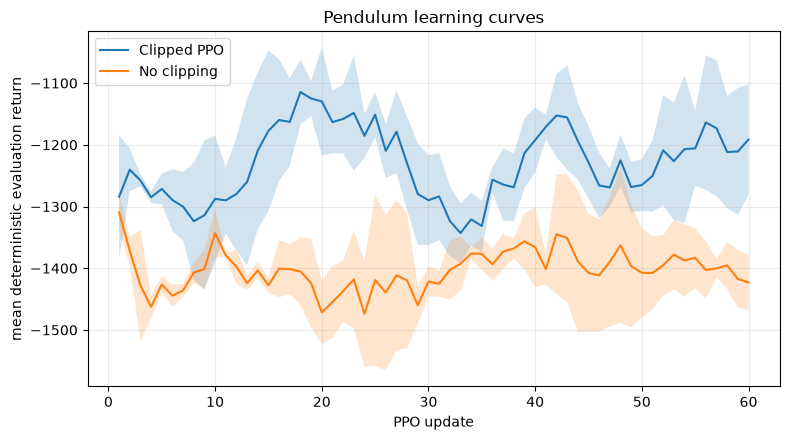

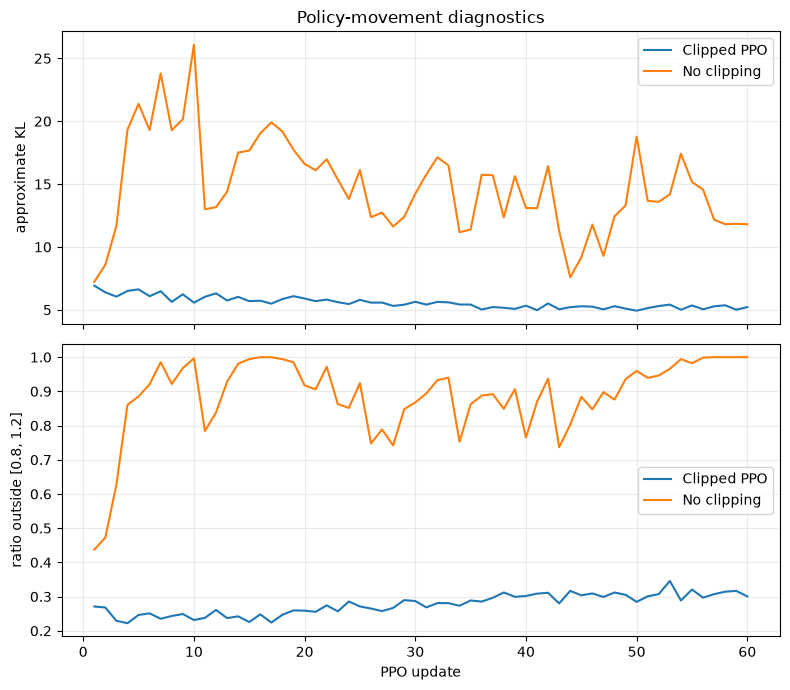

In [17]:
fig, axis = plt.subplots(figsize=(8, 4.5))
for variant_label, runs in task2_runs.items():
    curves = np.array([run["history"]["eval_return"] for run in runs])
    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)
    updates = np.arange(1, len(mean_curve) + 1)
    axis.plot(updates, mean_curve, label=variant_label)
    axis.fill_between(updates, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)

axis.set(
    title="Pendulum learning curves",
    xlabel="PPO update",
    ylabel="mean deterministic evaluation return",
)
axis.grid(alpha=0.25)
axis.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
for variant_label, runs in task2_runs.items():
    updates = np.arange(1, len(runs[0]["history"]["approx_kl"]) + 1)
    mean_kl = np.array([run["history"]["approx_kl"] for run in runs]).mean(axis=0)
    mean_outside = np.array(
        [run["history"]["clip_fraction"] for run in runs]
    ).mean(axis=0)
    axes[0].plot(updates, mean_kl, label=variant_label)
    axes[1].plot(updates, mean_outside, label=variant_label)

axes[0].set(title="Policy-movement diagnostics", ylabel="approximate KL")
axes[1].set(xlabel="PPO update", ylabel="ratio outside [0.8, 1.2]")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()


## Submission

The table reports each seed and the mean across seeds. Higher Pendulum return is better because the reward is negative.

Submit one executed notebook containing:

1. Your **implemented functions**: _distribution_and_value() and _squash_and_scale().
2. The **learning curve** and **policy-movement diagnostics**.
3. The per-seed and aggregate **result tables**.
4. An **evidence-based** comparison of clipped versus un-clipped PPO. Refer to both return and KL / ratio-movement results, and explain whether clipping improved stability for these runs.


In [ ]:
task2_rows = []
for variant_label, runs in task2_runs.items():
    for run in runs:
        history = run["history"]
        task2_rows.append(
            {
                "variant": variant_label,
                "seed": run["seed"],
                "final_30_episode_return": run["final_return"],
                "late_approx_kl": float(np.mean(history["approx_kl"][-10:])),
                "late_ratio_outside_range": float(
                    np.mean(history["clip_fraction"][-10:])
                ),
            }
        )

task2_seed_table = pd.DataFrame(task2_rows)
task2_summary_table = (
    task2_seed_table.groupby("variant")
    .agg(
        return_mean=("final_30_episode_return", "mean"),
        return_std=("final_30_episode_return", "std"),
        approx_kl_mean=("late_approx_kl", "mean"),
        outside_range_mean=("late_ratio_outside_range", "mean"),
    )
    .round(3)
)
display(task2_seed_table.round(3))
display(task2_summary_table)
